# PO versus moved-cue PO ratemaps by lap

Select one VS session containing both ordinary PO-family laps and moved-cue POM-family laps. The main figure compares one cell's smoothed per-lap ratemaps on a common physical `0-100` track axis:

- top row: `PO`, `PO2`, `PO3`, and `PONM`
- bottom row: `POM` and `POMB`
- columns: forward (`W`) and backward (`B`) laps

Stored backward laps may be direction-relative (`0 -> 100`). Their spatial columns are mirrored for plotting when needed, so backward panels are displayed on the same physical track axis as forward panels. Ratemap construction itself is unchanged. Gold axis markers show cue-rich spans without tinting the heatmap.

In [19]:
from pathlib import Path
from collections import Counter
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (repo_root / 'src' / 'placefields').is_dir():
    repo_root = repo_root.parent
if not (repo_root / 'src' / 'placefields').is_dir():
    raise RuntimeError('Could not find repository root containing src/placefields')

sys.path.insert(0, str(repo_root / 'src'))

from placefields import (
    RatemapConfig,
    build_default_xbin,
    build_ratemap_from_trials,
    build_trial_info_from_traj,
    canonical_condition_name,
    condition_family_name,
    cue_zone_layout_for_condition,
    decode_condway,
    ifreq_swap,
    load_traj_condition_names,
    matlab_1b_to_python_0b,
    normalize_x_to_100,
)
from placefields.interim_io import (
    find_pairs,
    load_allcel_spikes,
    load_traj_fields,
    stitch_trial_series,
)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

repo_root


WindowsPath('C:/Users/tadse/OneDrive/Documenti/GitHub/CA1-cellclass')

## Configuration

Set `SESSION_ID` to one of the sessions printed below. Set `CELL_ID` to inspect a specific neuron. When `CELL_ID = None`, the notebook chooses the cell with the largest peak in its PO/POM mean smoothed ratemap after excluding high-rate units above `AUTO_MAX_RUNNING_RATE_HZ`. This is a visualization heuristic, not a formal cell-type classification.

In [20]:
INTERIM_ROOT = repo_root / 'data' / 'interim'

# Eligible PO/POM sessions with MIN_NEURONS = 10.
# Format: SESSION_ID | n_cells | PO W/B laps | POM W/B laps
# VS101_2024-11-05_17-44-14 | 16 | PO 11/10 | POM 0/4
# VS104_2024-11-10_16-39-46 | 20 | PO 11/10 | POM 0/9
# VS106_2024-11-12_14-55-21 | 11 | PO 11/10 | POM 0/4
# VS109_2024-12-20_17-20-40 | 15 | PO 10/8 | POM 10/12
# VS109_2024-12-21_17-14-39 | 42 | PO 10/8 | POM 9/11
# VS110_2024-12-23_16-30-17 | 18 | PO 10/8 | POM 7/9
# VS111_2024-12-24_15-13-11 | 20 | PO 10/8 | POM 8/8
# VS116_2025-02-22_18-19-46 | 32 | PO 10/8 | POM 8/10
# VS116_2025-02-23_18-33-27 | 22 | PO 5/4 | POM 2/3
# VS118_2025-02-24_18-20-07 | 24 | PO 5/4 | POM 2/3
# VS118_2025-02-25_17-38-19 | 13 | PO 5/4 | POM 5/6
SESSION_ID = 'VS109_2024-12-21_17-14-39'
CELL_ID = None
MIN_NEURONS = 10
AUTO_MAX_RUNNING_RATE_HZ = 10.0

SPIKE_FREQ_HZ = 25_000.0
BEHAVIOR_FREQ_HZ = 1_000.0
MIN_SPEED = 2.0
SMOOTH_SIGMA_BINS = 2.8
XBIN_REM = 0
NORMALIZE_X_TO_100 = True

COLOR_PERCENTILE = 99.0
PLOT_MEAN_PROFILES = True


In [21]:
def count_recorded_cells(allcel_path):
    with np.load(allcel_path, allow_pickle=False) as z:
        if 'allcel__id_cel' not in z.files:
            return None
        return int(np.asarray(z['allcel__id_cel']).size)


def build_condition_name_map(traj_path):
    cond_raw, names_raw = load_traj_condition_names(traj_path)
    out = {}
    for cond in np.unique(cond_raw.astype(np.int64, copy=False)):
        names = [
            canonical_condition_name(name)
            for name in names_raw[cond_raw == cond].tolist()
            if canonical_condition_name(name)
        ]
        if names:
            counts = Counter(names)
            out[int(cond)] = sorted(counts.items(), key=lambda item: (-item[1], item[0]))[0][0]
    return out


def direction_counts_for_session(traj_path, condition_name_map):
    with np.load(traj_path, allow_pickle=False) as z:
        cond = np.asarray(z['traj__Cond']).ravel().astype(np.int64)
        wb = np.asarray(z['traj__WB']).astype(str).ravel()
    counts = Counter(
        (condition_family_name(condition_name_map.get(int(base_condition), '')), str(direction).upper())
        for base_condition, direction in zip(cond, wb)
    )
    return counts


def discover_po_pom_sessions(interim_root, min_neurons):
    rows = []
    for session_id, allcel_path, traj_path in find_pairs(interim_root, set()):
        n_cells = count_recorded_cells(allcel_path)
        if n_cells is None or n_cells < int(min_neurons):
            continue
        condition_name_map = build_condition_name_map(traj_path)
        families = sorted({condition_family_name(name) for name in condition_name_map.values()})
        if {'PO', 'POM'}.issubset(families):
            counts = direction_counts_for_session(traj_path, condition_name_map)
            rows.append(
                {
                    'session_id': session_id,
                    'n_cells': n_cells,
                    'families': ', '.join(families),
                    'po_w_laps': counts[('PO', 'W')],
                    'po_b_laps': counts[('PO', 'B')],
                    'pom_w_laps': counts[('POM', 'W')],
                    'pom_b_laps': counts[('POM', 'B')],
                    'allcel_path': allcel_path,
                    'traj_path': traj_path,
                }
            )
    return pd.DataFrame(rows).sort_values('session_id').reset_index(drop=True)


available_sessions = discover_po_pom_sessions(INTERIM_ROOT, MIN_NEURONS)
if available_sessions.empty:
    raise RuntimeError(f'No PO/POM sessions with at least {MIN_NEURONS} cells under {INTERIM_ROOT}')

display(
    available_sessions[
        ['session_id', 'n_cells', 'po_w_laps', 'po_b_laps', 'pom_w_laps', 'pom_b_laps', 'families']
    ]
)


,session_id,n_cells,po_w_laps,po_b_laps,pom_w_laps,pom_b_laps,families
0,VS101_2024-11-05_17-44-14,16,11,10,0,4,"PO, POM"
1,VS104_2024-11-10_16-39-46,20,11,10,0,9,"PO, POM"
2,VS106_2024-11-12_14-55-21,11,11,10,0,4,"PO, POM"
3,VS109_2024-12-20_17-20-40,15,10,8,10,12,"PO, POM"
4,VS109_2024-12-21_17-14-39,42,10,8,9,11,"PO, POM"
5,VS110_2024-12-23_16-30-17,18,10,8,7,9,"PO, POM"
6,VS111_2024-12-24_15-13-11,20,10,8,8,8,"PO, POM"
7,VS116_2025-02-22_18-19-46,32,10,8,8,10,"PO, POM"
8,VS116_2025-02-23_18-33-27,22,5,4,2,3,"PO, POM"
9,VS118_2025-02-24_18-20-07,24,5,4,2,3,"PO, POM"


In [22]:
selected_rows = available_sessions[available_sessions['session_id'] == SESSION_ID]
if selected_rows.empty:
    raise RuntimeError(f'SESSION_ID is not an eligible PO/POM session: {SESSION_ID}')

selected = selected_rows.iloc[0]
allcel_path = Path(selected['allcel_path'])
traj_path = Path(selected['traj_path'])

itime_25k, id_spk, id_cel = load_allcel_spikes(allcel_path)
with np.load(allcel_path, allow_pickle=False) as z:
    def optional_per_cell_field(key):
        if key not in z.files:
            return np.full(np.asarray(id_cel).size, np.nan, dtype=float)
        values = np.asarray(z[key]).ravel()
        if values.size != np.asarray(id_cel).size:
            return np.full(np.asarray(id_cel).size, np.nan, dtype=float)
        return values

    legacy_cell_metadata = pd.DataFrame(
        {
            'cell_id': np.asarray(id_cel).ravel().astype(np.int64),
            'legacy_type_u': optional_per_cell_field('allcel__type_u'),
            'legacy_type_u_old': optional_per_cell_field('allcel__type_u_old'),
            'saved_fr_u_hz': optional_per_cell_field('allcel__fr_u'),
            'saved_ref_per_u': optional_per_cell_field('allcel__ref_per_u'),
        }
    )
cond, wb, start, stop, vr_list, speed_list = load_traj_fields(traj_path)
condition_name_map = build_condition_name_map(traj_path)

position_x = stitch_trial_series(start, stop, vr_list)
if NORMALIZE_X_TO_100:
    position_x = normalize_x_to_100(position_x)

if speed_list is None and MIN_SPEED is not None:
    raise RuntimeError('This session has no XSpeed/Speed field; set MIN_SPEED = None to continue without speed filtering')
speed = stitch_trial_series(start, stop, speed_list) if speed_list is not None else None

trials = build_trial_info_from_traj(
    cond=cond,
    wb=wb,
    start_1b=start,
    stop_1b=stop,
    n_samples=int(position_x.size),
)
spike_idx_1b = ifreq_swap(itime_25k, SPIKE_FREQ_HZ, BEHAVIOR_FREQ_HZ)
spike_idx_0b = matlab_1b_to_python_0b(spike_idx_1b)
xbin_edges = build_default_xbin(position_x)

rmap = build_ratemap_from_trials(
    position_x=position_x,
    spike_indices_0b=spike_idx_0b,
    spike_cell_ids=id_spk,
    cell_ids=id_cel,
    trials=trials,
    xbin_edges=xbin_edges,
    cfg=RatemapConfig(
        freq_hz=BEHAVIOR_FREQ_HZ,
        smooth_sigma_bins=SMOOTH_SIGMA_BINS,
        xbin_rem=XBIN_REM,
        min_speed=MIN_SPEED,
    ),
    speed=speed,
)

print('session:', SESSION_ID)
print('allcel:', allcel_path)
print('trajdata:', traj_path)
print('cells / trials / bins:', rmap.cell_ids.size, len(trials), rmap.xbin_centers.size)
print('condition names:', condition_name_map)


session: VS109_2024-12-21_17-14-39
allcel: C:\Users\tadse\OneDrive\Documenti\GitHub\CA1-cellclass\data\interim\VS109\2024-12-21\VS109_2024-12-21_17-14-39_allcel.npz
trajdata: C:\Users\tadse\OneDrive\Documenti\GitHub\CA1-cellclass\data\interim\VS109\2024-12-21\VS109_2024-12-21_17-14-39_trajdata.npz
cells / trials / bins: 42 38 100
condition names: {1: 'PONM', 2: 'POM', 3: 'PONM', 4: 'POM'}


In [23]:
def trial_condition_name(trial):
    base_condition, _ = decode_condway(int(trial.condway))
    return condition_name_map.get(int(base_condition), f'cond{base_condition}')


def trial_family(trial):
    return condition_family_name(trial_condition_name(trial))


def trial_direction(trial):
    _, direction = decode_condway(int(trial.condway))
    return direction


def should_flip_backward_for_common_axis():
    deltas = []
    for trial in trials:
        if trial_direction(trial) != 'B':
            continue
        values = position_x[int(trial.start_idx_0b):int(trial.stop_idx_0b_exclusive)]
        values = values[np.isfinite(values)]
        if values.size >= 2:
            deltas.append(float(values[-1] - values[0]))
    return bool(deltas and np.nanmedian(np.asarray(deltas, dtype=float)) > 0)


def indices_for_panel(family, direction):
    return np.asarray(
        [
            index
            for index, trial in enumerate(trials)
            if trial_family(trial) == family and trial_direction(trial) == direction
        ],
        dtype=np.int64,
    )


def panel_maps(cell_index, family, direction):
    indices = indices_for_panel(family, direction)
    heat = rmap.fr_s_tx_ux[int(cell_index), indices, :].astype(float, copy=True)
    if flip_backward and direction == 'B':
        heat = heat[:, ::-1]
    return indices, heat


flip_backward = should_flip_backward_for_common_axis()
relevant_indices = np.asarray(
    [index for index, trial in enumerate(trials) if trial_family(trial) in {'PO', 'POM'}],
    dtype=np.int64,
)
if relevant_indices.size == 0:
    raise RuntimeError('Selected session has no PO/POM laps')

relevant_dwell_s = float(np.sum(rmap.dwell_tx_x[relevant_indices, :]))
relevant_spikes_by_cell = np.sum(rmap.nbspk_tx_ux[:, relevant_indices, :], axis=(1, 2))
running_rate_by_cell = relevant_spikes_by_cell / relevant_dwell_s
mean_maps = np.nanmean(rmap.fr_s_tx_ux[:, relevant_indices, :], axis=1)
peak_scores = np.nanmax(mean_maps, axis=1)
auto_eligible = np.isfinite(peak_scores) & (running_rate_by_cell <= float(AUTO_MAX_RUNNING_RATE_HZ))
cell_audit = pd.DataFrame(
    {
        'cell_id': rmap.cell_ids.astype(np.int64),
        'po_pom_running_rate_hz': running_rate_by_cell,
        'po_pom_mean_map_peak_hz': peak_scores,
        'auto_eligible': auto_eligible,
    }
).merge(legacy_cell_metadata, on='cell_id', how='left')
cell_audit = cell_audit.sort_values(['auto_eligible', 'po_pom_mean_map_peak_hz'], ascending=[False, False]).reset_index(drop=True)

if CELL_ID is None:
    if not np.any(auto_eligible):
        raise RuntimeError(f'No cell passes AUTO_MAX_RUNNING_RATE_HZ={AUTO_MAX_RUNNING_RATE_HZ}')
    eligible_indices = np.flatnonzero(auto_eligible)
    cell_index = int(eligible_indices[np.nanargmax(peak_scores[eligible_indices])])
    cell_selection = f'largest PO/POM mean-map peak with running rate <= {AUTO_MAX_RUNNING_RATE_HZ:g} Hz'
else:
    cell_index = rmap.cell_index(int(CELL_ID))
    cell_selection = 'configured CELL_ID'
cell_id = int(rmap.cell_ids[cell_index])
if running_rate_by_cell[cell_index] > float(AUTO_MAX_RUNNING_RATE_HZ):
    print(
        f'Warning: selected cell {cell_id} has PO/POM running rate '
        f'{running_rate_by_cell[cell_index]:.2f} Hz, above AUTO_MAX_RUNNING_RATE_HZ={AUTO_MAX_RUNNING_RATE_HZ:g}.'
    )

summary_rows = []
for family in ('PO', 'POM'):
    for direction in ('W', 'B'):
        indices = indices_for_panel(family, direction)
        labels = sorted({trial_condition_name(trials[index]) for index in indices})
        summary_rows.append(
            {
                'family': family,
                'direction': direction,
                'n_laps': int(indices.size),
                'grouped_labels': ', '.join(labels),
                'session_trial_numbers': ', '.join(str(int(index) + 1) for index in indices),
            }
        )

print('cell:', cell_id, '| index:', cell_index, '| selected by:', cell_selection)
print('mirror stored B columns onto physical axis:', flip_backward)
display(cell_audit)
display(pd.DataFrame(summary_rows))


cell: 104 | index: 28 | selected by: largest PO/POM mean-map peak with running rate <= 10 Hz
mirror stored B columns onto physical axis: True


,cell_id,po_pom_running_rate_hz,po_pom_mean_map_peak_hz,auto_eligible,legacy_type_u,legacy_type_u_old,saved_fr_u_hz,saved_ref_per_u
0,104,9.564527,11.253170,True,0,0,9.628516,3.0
1,91,7.251331,8.830024,True,1,0,7.793409,3.0
2,113,6.329197,7.471949,True,1,0,6.421299,3.0
3,10,5.113656,7.156115,True,0,0,5.927390,5.0
4,9,4.283211,6.432132,True,0,1,4.128138,4.0
5,109,3.981945,5.616292,True,0,0,4.397660,2.0
6,66,4.016001,5.480853,True,0,0,3.624807,3.0
7,118,4.026480,4.883157,True,0,1,3.722560,5.0
8,120,4.440393,4.463448,True,1,1,4.069804,3.0
9,14,3.395132,4.333227,True,0,0,3.563109,6.0


,family,direction,n_laps,grouped_labels,session_trial_numbers
0,PO,W,10,PONM,"1, 3, 5, 7, 9, 19, 21, 23, 25, 27"
1,PO,B,8,PONM,"2, 4, 6, 8, 20, 22, 24, 26"
2,POM,W,9,POM,"11, 13, 15, 17, 29, 31, 33, 35, 37"
3,POM,B,11,POM,"10, 12, 14, 16, 18, 28, 30, 32, 34, 36, 38"


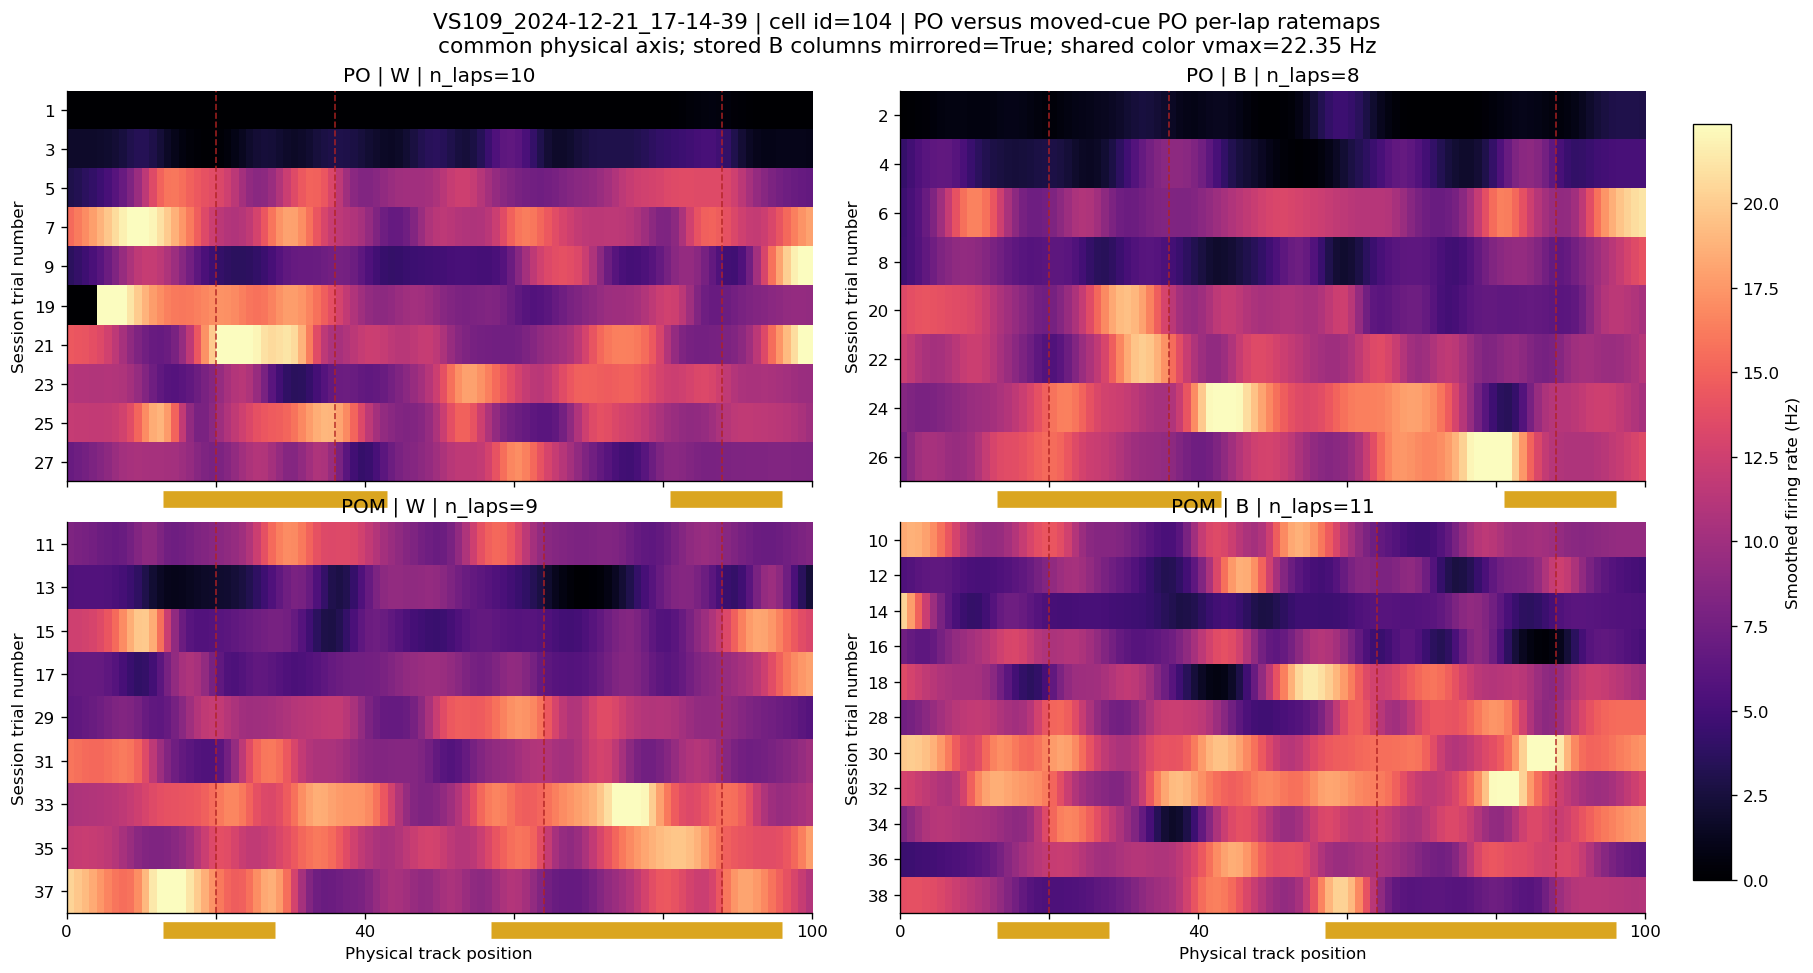

In [26]:
def draw_cue_axis_markers(ax, family):
    layout = cue_zone_layout_for_condition(family, condition_family=family)
    for start, end in layout.rich_spans:
        ax.plot(
            [start, end],
            [-0.045, -0.045],
            transform=ax.get_xaxis_transform(),
            color='goldenrod',
            lw=10,
            solid_capstyle='butt',
            clip_on=False,
            zorder=5,
        )
    for center in layout.object_centers:
        ax.axvline(center, color='firebrick', ls='--', lw=1.0, alpha=0.85, zorder=4)


families = ('PO', 'POM')
directions = ('W', 'B')
panel_data = {}
finite_values = []
for family in families:
    for direction in directions:
        indices, heat = panel_maps(cell_index, family, direction)
        panel_data[(family, direction)] = (indices, heat)
        finite = heat[np.isfinite(heat)]
        if finite.size:
            finite_values.append(finite)

if not finite_values:
    raise RuntimeError('No finite PO/POM ratemap values available for plotting')
vmax = float(np.nanpercentile(np.concatenate(finite_values), COLOR_PERCENTILE))
if not np.isfinite(vmax) or vmax <= 0:
    vmax = 1.0

fig, axs = plt.subplots(2, 2, figsize=(15, 8), sharex=True, constrained_layout=True)
last_image = None
for row, family in enumerate(families):
    for col, direction in enumerate(directions):
        ax = axs[row, col]
        indices, heat = panel_data[(family, direction)]
        if heat.shape[0]:
            last_image = ax.imshow(
                heat,
                aspect='auto',
                origin='upper',
                extent=[rmap.xbin_edges[0], rmap.xbin_edges[-1], heat.shape[0] - 0.5, -0.5],
                cmap='magma',
                vmin=0.0,
                vmax=vmax,
                interpolation='nearest',
            )
            ax.set_yticks(np.arange(indices.size))
            ax.set_yticklabels([str(int(index) + 1) for index in indices])
        else:
            ax.text(0.5, 0.5, 'No laps', transform=ax.transAxes, ha='center', va='center', color='0.4')
        draw_cue_axis_markers(ax, family)
        ax.set_xlim(float(rmap.xbin_edges[0]), float(rmap.xbin_edges[-1]))
        ax.set_title(f'{family} | {direction} | n_laps={indices.size}')
        ax.set_ylabel('Session trial number')
        if row == 1:
            ax.set_xlabel('Physical track position')

if last_image is not None:
    fig.colorbar(last_image, ax=axs, label='Smoothed firing rate (Hz)', shrink=0.92, pad=0.02)
fig.suptitle(
    f'{SESSION_ID} | cell id={cell_id} | PO versus moved-cue PO per-lap ratemaps\n'
    f'common physical axis; stored B columns mirrored={flip_backward}; shared color vmax={vmax:.2f} Hz',
    fontsize=13,
)
plt.show()


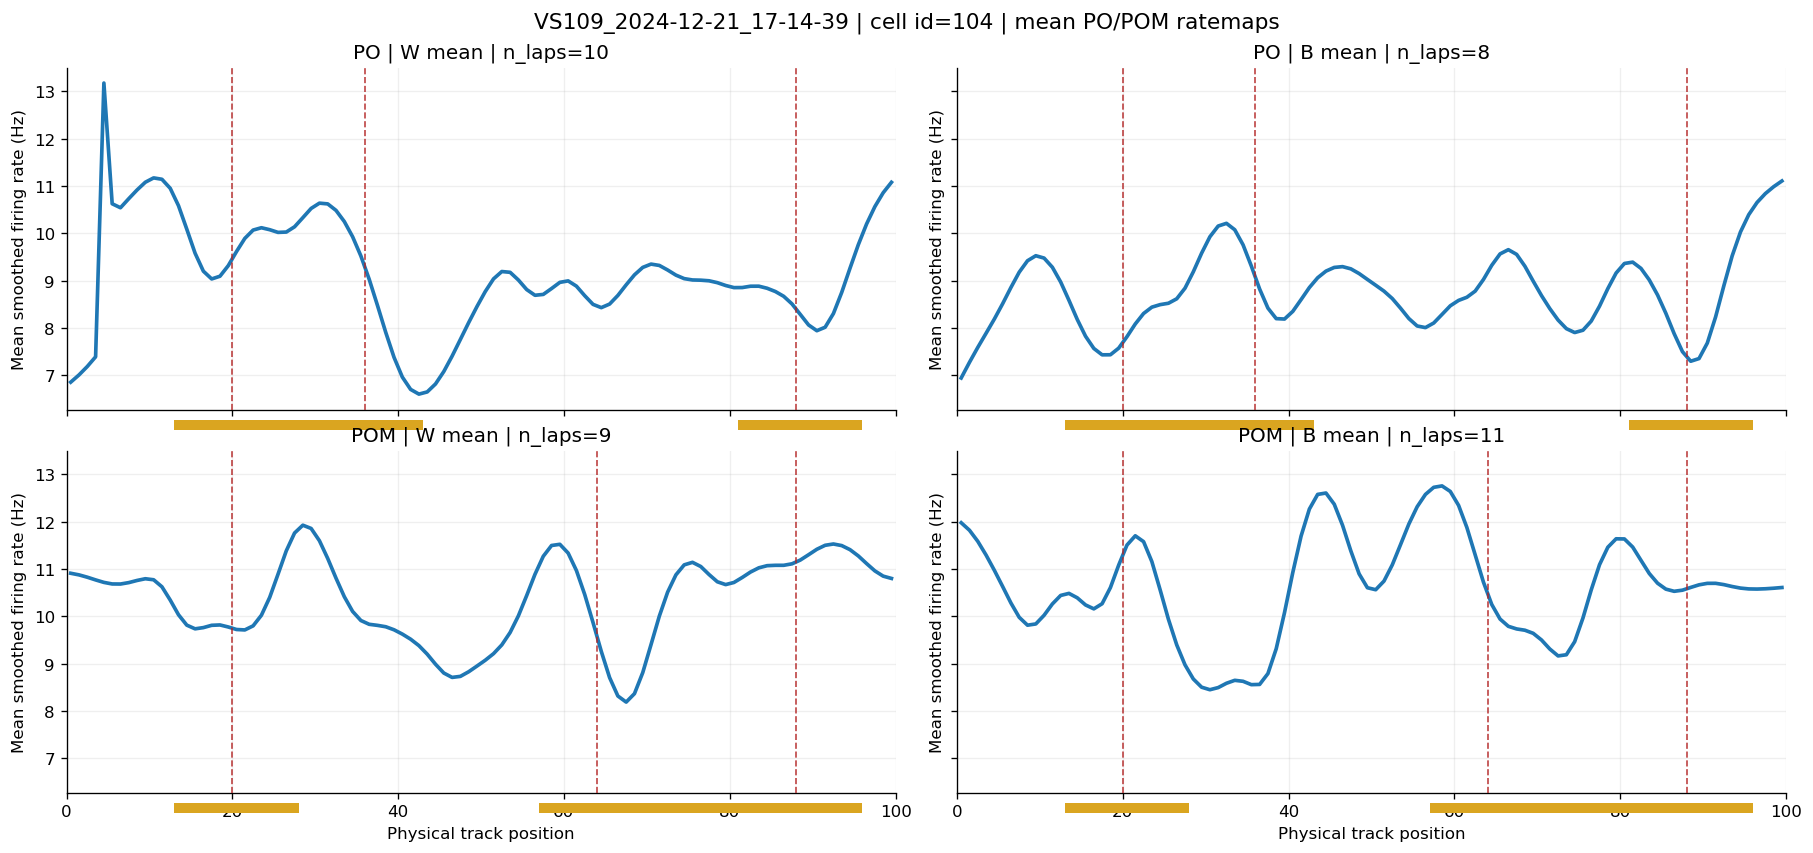

In [25]:
if PLOT_MEAN_PROFILES:
    fig, axs = plt.subplots(2, 2, figsize=(15, 7), sharex=True, sharey=True, constrained_layout=True)
    for row, family in enumerate(families):
        for col, direction in enumerate(directions):
            ax = axs[row, col]
            indices, heat = panel_data[(family, direction)]
            if heat.shape[0]:
                ax.plot(rmap.xbin_centers, np.nanmean(heat, axis=0), color='tab:blue', lw=2.2)
            else:
                ax.text(0.5, 0.5, 'No laps', transform=ax.transAxes, ha='center', va='center', color='0.4')
            draw_cue_axis_markers(ax, family)
            ax.set_xlim(float(rmap.xbin_edges[0]), float(rmap.xbin_edges[-1]))
            ax.set_title(f'{family} | {direction} mean | n_laps={indices.size}')
            ax.set_ylabel('Mean smoothed firing rate (Hz)')
            ax.grid(alpha=0.2)
            if row == 1:
                ax.set_xlabel('Physical track position')
    fig.suptitle(f'{SESSION_ID} | cell id={cell_id} | mean PO/POM ratemaps', fontsize=13)
    plt.show()


## Notes

- A shared color scale is used across the four heatmaps. `COLOR_PERCENTILE` limits the influence of extreme rate bins while keeping the panels comparable.
- Automatic cell selection excludes high-rate units above `AUTO_MAX_RUNNING_RATE_HZ`. Set `CELL_ID` explicitly to inspect any recorded unit, including excluded units.
- The audit table includes legacy `allcel` labels for context. These are not used for automatic selection because legacy labels may disagree and the newer GMM classification table does not cover every VS session.
- Y-axis labels are the original session trial numbers, which makes condition-block order visible.
- Backward columns are mirrored only for common-axis presentation. The underlying traversal-relative maps are not modified.